In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
llm = ChatOpenAI()

def chat_node(state: ChatState):
    #take user query from state
    messages = state['messages']

    #send to llm
    response = llm.invoke(messages)

    #response store state
    return {'messages': [response]}

In [5]:
graph = StateGraph(ChatState)

#add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

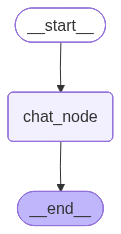

In [6]:
chatbot

In [8]:
initial_state = {
    'messages':  [HumanMessage(content='What do you think about the future of AI in Job market for AI engineer')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'I believe that the future of AI in the job market for AI engineers is bright. As AI technology continues to advance, the demand for skilled AI engineers will only increase. Companies across various industries will be looking for talent who can design, develop, and implement AI solutions to improve their products and services. As a result, AI engineers will have plenty of job opportunities and the potential for high salaries. Additionally, AI engineers will have the chance to work on cutting-edge projects and contribute to the evolution of AI technology. Overall, I believe that the job market for AI engineers will continue to grow and flourish in the future.'

In [ ]:
while True:
    user_message = input('Type here: ')
    print("User: ", user_message)
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
    print('AI: ', response['messages'][-1].content)